# Scaling Experiment Adult Census

## Цель этапа

Сравнить влияние разных методов масштабирования числовых признаков на Logistic Regression.

## Импорт библиотек и настройка путей

Во всех вариантах используется один train/test split, одинаковая модель и одинаковая обработка категориальных признаков.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "adult-census.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
RANDOM_STATE = 42

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression

from src.experiment_utils import (
    load_adult_data,
    split_features_target,
    get_feature_groups,
    calculate_metrics,
    save_results,
)

def get_positive_proba(model, X_test):
    positive_index = list(model.classes_).index(">50K")
    return model.predict_proba(X_test)[:, positive_index]

import matplotlib.pyplot as plt
import seaborn as sns
from src.experiment_utils import save_figure

sns.set_theme(style="whitegrid", context="notebook")

## Загрузка данных и split

`train_test_split` выполняется до обучения pipeline. Все операции `fit` для preprocessing происходят только на train-части.

In [2]:
df = load_adult_data(DATA_PATH)
X, y = split_features_target(df)
numeric_features, categorical_features = get_feature_groups(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

pd.DataFrame({"Numeric features": [len(numeric_features)], "Categorical features": [len(categorical_features)]})

,Numeric features,Categorical features
0,5,8


## Варианты масштабирования

Сравниваются три numeric pipeline: без масштабирования, со `StandardScaler` и с `MinMaxScaler`.

In [3]:
scaling_variants = {
    "No scaling": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]),
    "StandardScaler": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]),
    "MinMaxScaler": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
    ]),
}

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

list(scaling_variants.keys())

['No scaling', 'StandardScaler', 'MinMaxScaler']

## Обучение моделей

Для каждого варианта создается отдельный `Pipeline`: `preprocessor -> classifier`. Различается только обработка числовых признаков.

In [4]:
rows = []

for preprocessing_name, numeric_transformer in scaling_variants.items():
    preprocessor = ColumnTransformer([
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ])
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=3000, solver="liblinear")),
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = get_positive_proba(model, X_test)
    rows.append({
        "Dataset": "Adult",
        "Experiment": "Scaling",
        "Model": "LogisticRegression",
        "Preprocessing": preprocessing_name,
        **calculate_metrics(y_test, y_pred, y_proba),
    })

scaling_results = pd.DataFrame(rows).round(4)
scaling_results

,Dataset,Experiment,Model,Preprocessing,Accuracy,F1-score,ROC-AUC
0,Adult,Scaling,LogisticRegression,No scaling,0.8520,0.6539,0.9012
1,Adult,Scaling,LogisticRegression,StandardScaler,0.8525,0.6568,0.9040
2,Adult,Scaling,LogisticRegression,MinMaxScaler,0.8525,0.6547,0.9021


## Сохранение таблицы результатов

Результаты эксперимента сохраняются в `results/scaling_results.csv`.

In [5]:
save_results(scaling_results, RESULTS_DIR / "scaling_results.csv")
scaling_results

,Dataset,Experiment,Model,Preprocessing,Accuracy,F1-score,ROC-AUC
0,Adult,Scaling,LogisticRegression,No scaling,0.8520,0.6539,0.9012
1,Adult,Scaling,LogisticRegression,StandardScaler,0.8525,0.6568,0.9040
2,Adult,Scaling,LogisticRegression,MinMaxScaler,0.8525,0.6547,0.9021


## Сравнение F1-score

F1-score отражает качество распознавания положительного класса `>50K` с учетом precision и recall.

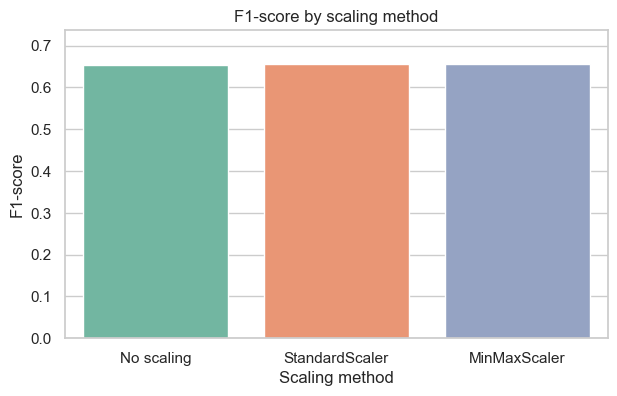

In [6]:
plt.figure(figsize=(7, 4))
sns.barplot(data=scaling_results, x="Preprocessing", y="F1-score", hue="Preprocessing", palette="Set2", legend=False)
plt.ylim(0, max(scaling_results["F1-score"]) + 0.08)
plt.title("F1-score by scaling method")
plt.xlabel("Scaling method")
plt.ylabel("F1-score")
save_figure(FIGURES_DIR / "scaling_f1_comparison.png")
plt.show()

## Сравнение ROC-AUC

ROC-AUC оценивает способность модели ранжировать объекты положительного класса выше объектов отрицательного класса.

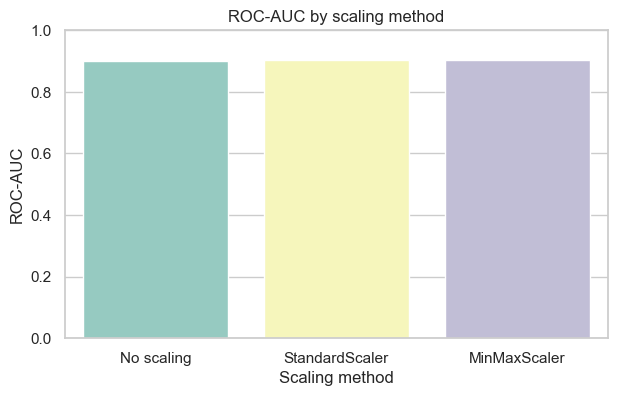

In [7]:
plt.figure(figsize=(7, 4))
sns.barplot(data=scaling_results, x="Preprocessing", y="ROC-AUC", hue="Preprocessing", palette="Set3", legend=False)
plt.ylim(0, 1)
plt.title("ROC-AUC by scaling method")
plt.xlabel("Scaling method")
plt.ylabel("ROC-AUC")
save_figure(FIGURES_DIR / "scaling_roc_auc_comparison.png")
plt.show()

## Вывод

Масштабирование дало небольшой эффект для Logistic Regression. `StandardScaler` улучшил F1-score с 0.6539 до 0.6568 и ROC-AUC с 0.9012 до 0.9040, но прирост ограниченный. Scaling полезен, но не является главным фактором качества для данной baseline-модели. Для SVM и MLP влияние масштабирования потенциально важнее, поэтому далее модели сравниваются на едином scaled pipeline.